# SONAR Rock vs Mine Prediction
### Logistic Regression from Scratch — No ML Libraries

In [33]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\youss\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Model import LogisticRegression

## 1. Load the Dataset

In [35]:
# The dataset has no headers, so we pass header=None
df = pd.read_csv("Copy of sonar data.csv", header=None)

# Assign meaningful column names: F1-F60 for features, Label for target
column_names = [f"F{i}" for i in range(1, 61)] + ['Label']
df.columns = column_names

df.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F52,F53,F54,F55,F56,F57,F58,F59,F60,Label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 2. Understand the Data

In [36]:
# Basic shape and data types
print("Shape:", df.shape)
print()
df.info()

Shape: (208, 61)

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      208 non-null    float64
 1   F2      208 non-null    float64
 2   F3      208 non-null    float64
 3   F4      208 non-null    float64
 4   F5      208 non-null    float64
 5   F6      208 non-null    float64
 6   F7      208 non-null    float64
 7   F8      208 non-null    float64
 8   F9      208 non-null    float64
 9   F10     208 non-null    float64
 10  F11     208 non-null    float64
 11  F12     208 non-null    float64
 12  F13     208 non-null    float64
 13  F14     208 non-null    float64
 14  F15     208 non-null    float64
 15  F16     208 non-null    float64
 16  F17     208 non-null    float64
 17  F18     208 non-null    float64
 18  F19     208 non-null    float64
 19  F20     208 non-null    float64
 20  F21     208 non-null    float64
 21  F22     208 non-null    float64


In [37]:
# Check for missing values — important before doing anything
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

Missing values per column:
0 total missing values


In [38]:
# Statistical summary of all features
df.describe()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F51,F52,F53,F54,F55,F56,F57,F58,F59,F60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


## 3. Class Distribution

Label
M    111
R     97
Name: count, dtype: int64


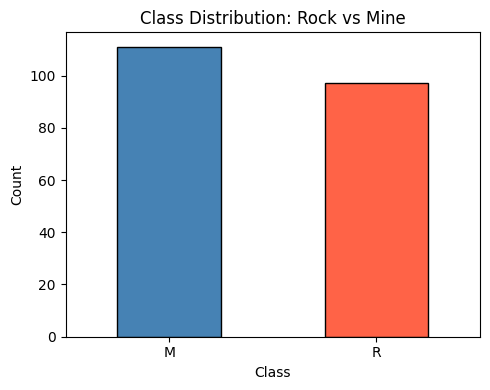

In [39]:
# How many Rock (R) vs Mine (M) samples do we have?
class_counts = df['Label'].value_counts()
print(class_counts)

plt.figure(figsize=(5, 4))
class_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title("Class Distribution: Rock vs Mine")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Distributions
Looking at how the first 12 features are distributed.

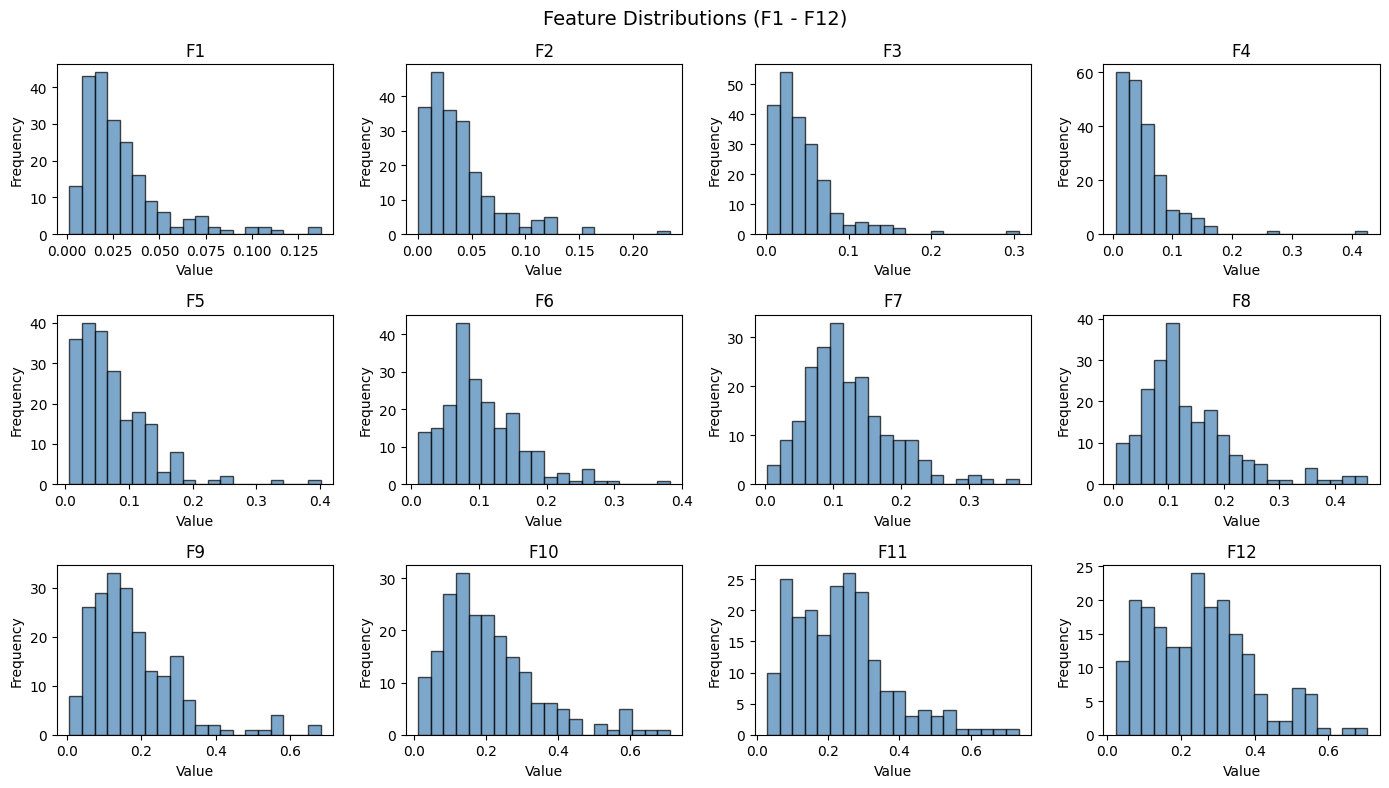

In [40]:
# Plot histograms for the first 12 features
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()

for i in range(12):
    axes[i].hist(df[f"F{i+1}"], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f"F{i+1}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Feature Distributions (F1 - F12)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Feature Comparison: Rock vs Mine
Do some features separate the two classes well?

C:\Users\youss\AppData\Local\Temp\ipykernel_71656\3042051714.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([rocks, mines], labels=['Rock', 'Mine'], patch_artist=True,
C:\Users\youss\AppData\Local\Temp\ipykernel_71656\3042051714.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([rocks, mines], labels=['Rock', 'Mine'], patch_artist=True,
C:\Users\youss\AppData\Local\Temp\ipykernel_71656\3042051714.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([rocks, mines], labels=['Rock', 'Mine'], patch_artist=True,
C:\Users\youss\AppData\Local\Temp\ipykernel_71656\30420517

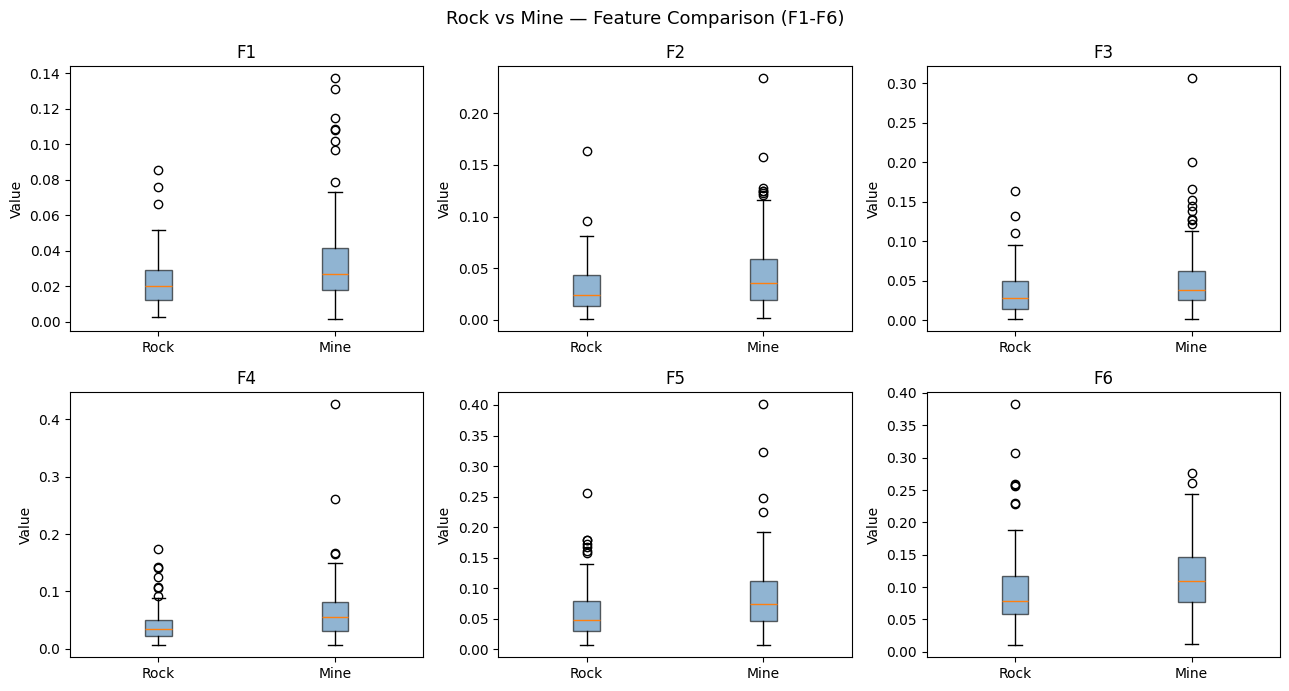

In [41]:
# Compare the first 6 features between Rock and Mine
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i in range(6):
    feature = f"F{i+1}"
    rocks = df[df['Label'] == 'R'][feature]
    mines = df[df['Label'] == 'M'][feature]
    axes[i].boxplot([rocks, mines], labels=['Rock', 'Mine'], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(feature)
    axes[i].set_ylabel("Value")

plt.suptitle("Rock vs Mine — Feature Comparison (F1-F6)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap
Checking if any features are highly correlated with each other.

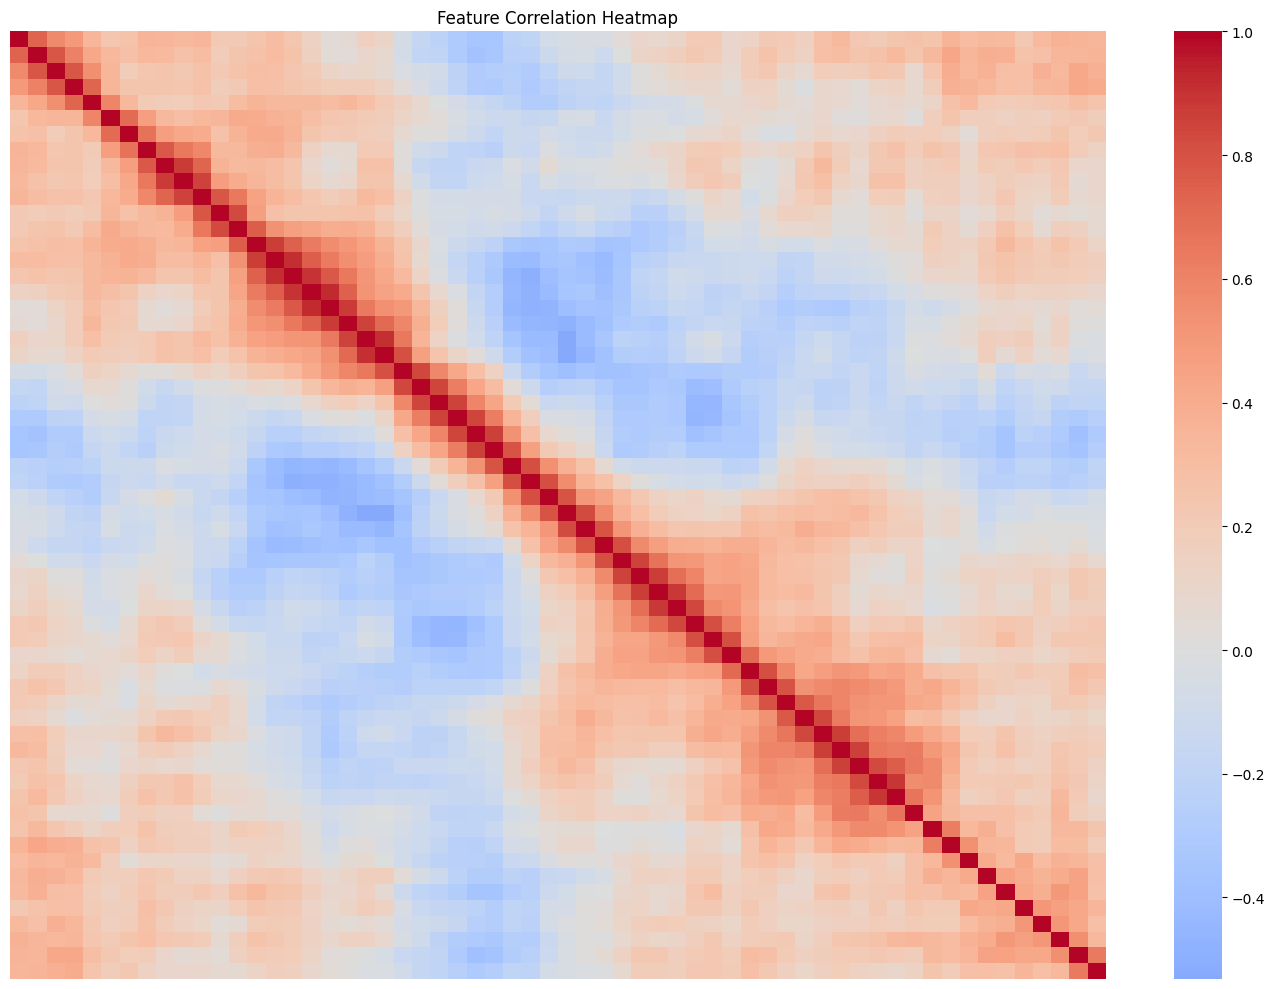

In [42]:
# Correlation matrix for all 60 features
plt.figure(figsize=(14, 10))
corr_matrix = df.drop(columns='Label').corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 7. Preprocessing

In [43]:
# Shuffle the dataset to remove any ordering bias
# random_state=42 keeps the shuffle consistent every run
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.columns = column_names

# Separate features and target
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [44]:
# Manual Train/Test Split — 80% train, 20% test
split_idx = int((80 / 100) * x.shape[0])

x_train = x.iloc[:split_idx, :]
x_test  = x.iloc[split_idx:, :]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train samples: {x_train.shape[0]}")
print(f"Test  samples: {x_test.shape[0]}")

Train samples: 166
Test  samples: 42


In [45]:
# Convert labels from strings to binary: Mine=1, Rock=0
y_train = np.where(y_train == "M", 1, 0)
y_test  = np.where(y_test  == "M", 1, 0)

In [46]:
# Min-Max Scaling — fit on train only to avoid data leakage
data_min = x_train.min()
data_max = x_train.max()

train_scaled = (x_train - data_min) / (data_max - data_min)
test_scaled  = (x_test  - data_min) / (data_max - data_min)

In [47]:
# Add bias column (all ones) as the first column
# This lets the model learn a bias term without a separate variable
x_train = np.c_[np.ones(train_scaled.shape[0]), train_scaled]
x_test  = np.c_[np.ones(test_scaled.shape[0]),  test_scaled]

print("x_train shape:", x_train.shape)
print("x_test  shape:", x_test.shape)

x_train shape: (166, 61)
x_test  shape: (42, 61)


## 8. Train the Model

In [59]:
# Run 10 times to get a reliable accuracy estimate
# Each run starts with different random weights
accuracies = []
for i in range(10):
    model = LogisticRegression(eta=0.01, epochs=10000)
    model.fit(x_train, y_train)
    accuracies.append(model.accuracy(x_test, y_test))

print(f"Mean Accuracy: {np.mean(accuracies):.4f}")
print(f"Std:           {np.std(accuracies):.4f}")
#print(f"Weight Vector: {model.weights[:5]}")
print(f"Bias:    {model.weights[0]:.4f}")
#print(f"Weights: {model.weights[1:]}")

Mean Accuracy: 0.8333
Std:           0.0000
Bias:    -1.7330


## 9. Learning Curve
Shows how the cost decreased during training.

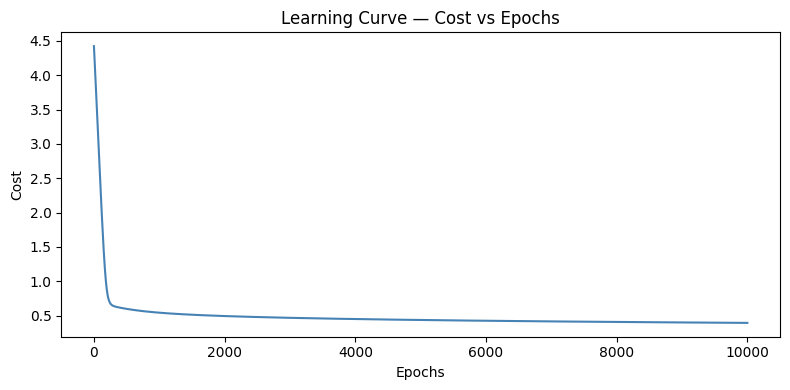

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(model.cost_history, color='steelblue')
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Learning Curve — Cost vs Epochs")
plt.tight_layout()
plt.show()